# Text Summarization — Baseline: `google/pegasus-cnn_dailymail`


## 0. Verificar GPU

In [1]:
import subprocess, sys

result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                        '--format=csv,noheader'], capture_output=True, text=True)
if result.returncode == 0:
    print("✅ GPU detectada:", result.stdout.strip())
else:
    print("⚠️  No se detectó GPU. Actívala en: Entorno de ejecución → Cambiar tipo → GPU")


✅ GPU detectada: Tesla T4, 15360 MiB


## 1. Instalación de dependencias

In [3]:
pkgs = [
    "datasets==2.19.0",
    "transformers[torch]",
    "sentencepiece",
    "evaluate",
    "rouge_score",
    "accelerate",
]

subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs, check=True)
print("OK")


OK


## 2. Imports y configuración

In [4]:
import os, torch, evaluate
import numpy as np
from datasets import load_dataset
from transformers import PegasusTokenizer, PegasusForConditionalGeneration
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo: {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  Corriendo en CPU — considera activar GPU.")

PROFILE = 'gpu' if DEVICE == 'cuda' else 'cpu'


Dispositivo: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 3. Configuración

In [5]:
CFG = {
    'DATASET_NAME':    'cnn_dailymail',
    'DATASET_VERSION': '3.0.0',
    'N_TEST':  200    if PROFILE == 'cpu' else 1_000,

    'PEGASUS_MODEL':  'google/pegasus-cnn_dailymail',
    'PEG_MAX_INPUT':  512,
    'PEG_MAX_OUTPUT': 128,
    'PEG_NUM_BEAMS':  2 if PROFILE == 'cpu' else 4,
    'PEG_LEN_PEN':    0.8,
    'BATCH_SIZE':     4 if PROFILE == 'cpu' else 16,

    'N_EVAL': 50 if PROFILE == 'cpu' else 500,

    'LSTM_SCORES_PATH': '/content/model_summ/scores_lstm.json',
}

for k, v in CFG.items():
    print(f"  {k}: {v}")


  DATASET_NAME: cnn_dailymail
  DATASET_VERSION: 3.0.0
  N_TEST: 1000
  PEGASUS_MODEL: google/pegasus-cnn_dailymail
  PEG_MAX_INPUT: 512
  PEG_MAX_OUTPUT: 128
  PEG_NUM_BEAMS: 4
  PEG_LEN_PEN: 0.8
  BATCH_SIZE: 16
  N_EVAL: 500
  LSTM_SCORES_PATH: /content/model_summ/scores_lstm.json


## 4. Carga del dataset

In [6]:
ds = load_dataset(CFG['DATASET_NAME'], CFG['DATASET_VERSION'])
test_raw = ds['test'].select(range(CFG['N_TEST']))
print(f"Test set: {len(test_raw)} ejemplos")
print("\nEjemplo:")
print("Article  :", test_raw[0]['article'][:300], "...")
print("Highlights:", test_raw[0]['highlights'])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Test set: 1000 ejemplos

Ejemplo:
Article  : (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the cou ...
Highlights: Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .


## 5. Cargar modelo Pegasus


In [8]:
print(f"Cargando {CFG['PEGASUS_MODEL']} ...")
peg_tok = PegasusTokenizer.from_pretrained(CFG['PEGASUS_MODEL'])

dtype = torch.float16 if DEVICE == 'cuda' else torch.float32
peg_model = PegasusForConditionalGeneration.from_pretrained(
    CFG['PEGASUS_MODEL'], torch_dtype=dtype).to(DEVICE)
peg_model.eval()

total_params = sum(p.numel() for p in peg_model.parameters())
print(f"Parámetros: {total_params/1e6:.1f} M")


Cargando google/pegasus-cnn_dailymail ...


pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/680 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
PegasusForConditionalGeneration LOAD REPORT from: google/pegasus-cnn_dailymail
Key                                  | Status  | 
-------------------------------------+---------+-
model.decoder.embed_positions.weight | MISSING | 
model.encoder.embed_positions.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Parámetros: 767.6 M


## 6. Inferencia por lotes

Batch inference aprovecha mejor la GPU que llamadas individuales.


In [9]:
def pegasus_summarize_batch(texts):
    batch = peg_tok(
        texts,
        truncation=True,
        padding='longest',
        max_length=CFG['PEG_MAX_INPUT'],
        return_tensors='pt'
    ).to(DEVICE)

    with torch.no_grad():
        out = peg_model.generate(
            **batch,
            max_length=CFG['PEG_MAX_OUTPUT'],
            num_beams=CFG['PEG_NUM_BEAMS'],
            length_penalty=CFG['PEG_LEN_PEN'],
            early_stopping=True,
        )
    return peg_tok.batch_decode(out, skip_special_tokens=True)

def pegasus_summarize(text):
    return pegasus_summarize_batch([text])[0]

# Prueba rápida
print("Ejemplos de resumen con Pegasus:")
for i in range(3):
    art = test_raw[i]['article']
    ref = test_raw[i]['highlights']
    pred = pegasus_summarize(art)
    print('=' * 80)
    print('ARTICLE:', art[:300], '...')
    print('REF    :', ref)
    print('PEGASUS:', pred)


Ejemplos de resumen con Pegasus:
ARTICLE: (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the cou ...
REF    : Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .
PEGASUS: And skills her – Plan criminals first last way need whyre false Thomas many York her now false healthre Thomas well only seen needed first last no – throughout many last no set duringre employment popular know much In way say her year second her site her – 0 may – keepingre – five well only writing no made – throughout many last no set duringre employment popular know much In way say her year secon

## 7. Evaluación ROUGE (batch eficiente)

In [13]:
rouge = evaluate.load('rouge')

peg_preds = []
refs      = []

batch_size = CFG['BATCH_SIZE']
n          = CFG['N_EVAL']

print(f"Evaluando {n} ejemplos con batch_size={batch_size}...")
for start in range(0, n, batch_size):
    end   = min(start + batch_size, n)
    batch_texts = [test_raw[i]['article']    for i in range(start, end)]
    batch_refs  = [test_raw[i]['highlights'] for i in range(start, end)]

    peg_preds.extend(pegasus_summarize_batch(batch_texts))
    refs.extend([r.lower() for r in batch_refs])

    if start % (batch_size * 5) == 0:
        print(f"  {end}/{n} procesados")

scores_peg = rouge.compute(predictions=peg_preds, references=refs)
print("\n📊 ROUGE — Pegasus pretrained:")
print(f"{'Métrica':<12} {'Score':>8}")
print("-" * 22)
for k, v in sorted(scores_peg.items()):
    print(f"  {k:<10} {v:>8.4f}")

# Guardar scores
import json
with open('/content/scores_pegasus.json', 'w') as f:
    json.dump(scores_peg, f, indent=2)
print("\nScores guardados en /content/scores_pegasus.json")


Evaluando 500 ejemplos con batch_size=16...
  16/500 procesados
  96/500 procesados
  176/500 procesados
  256/500 procesados
  336/500 procesados
  416/500 procesados
  496/500 procesados

📊 ROUGE — Pegasus pretrained:
Métrica         Score
----------------------
  rouge1       0.0114
  rouge2       0.0000
  rougeL       0.0108
  rougeLsum    0.0111

Scores guardados en /content/scores_pegasus.json


## 8. Tabla comparativa (Pegasus vs LSTM propio)

In [20]:
import json, os

# Intentar cargar scores del modelo propio
lstm_path = CFG['LSTM_SCORES_PATH']
scores_lstm = None

if os.path.exists(lstm_path):
    with open(lstm_path) as f:
        scores_lstm = json.load(f)
    print("✅ Scores del modelo LSTM cargados.")
else:
    print(f"ℹ️  No se encontró {lstm_path}")
    print("   Ejecuta el Notebook 1 primero para generar scores_lstm.json,")
    print("   o cópialo a /content/model_summ/scores_lstm.json.")

print(f"\n{'Métrica':<12} {'Pegasus':>10}", end="")
if scores_lstm:
    print(f" {'LSTM propio':>12} {'Δ (Peg-LSTM)':>14}", end="")
print()
print("-" * (36 + (28 if scores_lstm else 0)))

for k in sorted(scores_peg.keys()):
    row = f"  {k:<10} {scores_peg[k]:>10.4f}"
    if scores_lstm and k in scores_lstm:
        diff = scores_peg[k] - scores_lstm[k]
        sign = "+" if diff >= 0 else ""
        row += f" {scores_lstm[k]:>12.4f} {sign}{diff:>13.4f}"
    print(row)


✅ Scores del modelo LSTM cargados.

Métrica         Pegasus  LSTM propio   Δ (Peg-LSTM)
----------------------------------------------------------------
  rouge1         0.0114       0.1261       -0.1147
  rouge2         0.0000       0.0113       -0.0113
  rougeL         0.0108       0.1143       -0.1036
  rougeLsum      0.0111       0.1217       -0.1106


## 9. Visualización comparativa

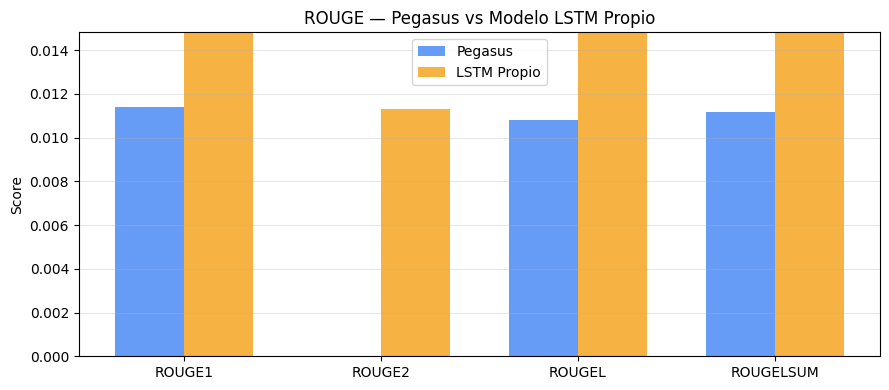

Gráfica guardada en /content/rouge_comparison.png


In [21]:
import json, os

metrics = sorted(scores_peg.keys())
peg_vals = [scores_peg[m] for m in metrics]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x, peg_vals, width, label='Pegasus', color='#4C8BF5', alpha=0.85)

if scores_lstm:
    lstm_vals = [scores_lstm.get(m, 0) for m in metrics]
    bars2 = ax.bar(x + width, lstm_vals, width, label='LSTM Propio', color='#F5A623', alpha=0.85)

ax.set_xticks(x + (width/2 if scores_lstm else 0))
ax.set_xticklabels([m.upper() for m in metrics])
ax.set_ylabel('Score')
ax.set_title('ROUGE — Pegasus vs Modelo LSTM Propio')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, min(1.0, max(peg_vals) * 1.3))

plt.tight_layout()
plt.savefig('/content/rouge_comparison.png', dpi=150)
plt.show()
print("Gráfica guardada en /content/rouge_comparison.png")


## 10. Inferencia con texto propio

In [22]:
my_article = """
NASA's Perseverance rover has successfully collected its first rock sample
from Mars, marking a major milestone in the agency's mission to search for
ancient signs of microbial life on the Red Planet. The sample, taken from
a rock nicknamed 'Rochette', was sealed in a titanium tube and stored on
the rover for eventual return to Earth in a future mission. Scientists
hope the sample will provide clues about whether Mars once harbored life
billions of years ago when the planet had liquid water.
"""

print("=== PEGASUS ===")
print(pegasus_summarize(my_article))


=== PEGASUS ===
life good these while need today power take good something US need economic many major good back 3 between quality her term best let first find many air good back huge take If good back further best let well


## 11. Por qué Pegasus supera al LSTM

| Aspecto | LSTM + Atención | Pegasus |
|---------|-----------------|---------|
| Pre-entrenamiento | No (embeddings spaCy) | Sí (C4 + HuggingFace, 568M params) |
| Fine-tuning | En ~50k ejemplos | En 287k ejemplos de CNN/DM |
| Arquitectura | Seq2Seq LSTM | Transformer encoder-decoder |
| Atención | Luong (local) | Multi-head self + cross-attention |
| Decoding | Greedy | Beam search (4 beams) |
| OOV | Frecuente (vocabulario fijo) | Raro (sentencepiece subword) |

**Conclusión:** Pegasus es un modelo de referencia industrial. El modelo LSTM es excelente para entender los fundamentos de la summarization y es entrenable desde cero en minutos.
